In [1]:
import numpy as np 

class Perceptron(object):
   
    def __init__(self, input_size, lr=0.2, epochs=4):
        self.W = np.array([0.3,-0.2])
        self.epochs = epochs
        self.lr = lr
    
    def activation_fn(self, x):
        return 1 if x >= 0 else 0
 
    def predict(self, x,theta):
        z = self.W.T.dot(x)-theta
        z=round(z,2)
        a = self.activation_fn(z)
        return a
    
    def fit(self, X, d,theta ,count):
        for _ in range(self.epochs):
            
            print("Epoch: ", count)
            count = count+1
            for i in range(d.shape[0]):
                x = X[i]
                print("input", x , "\t", "Weight:",self.W )
                y = self.predict(x,theta)
                e = d[i] - y
                self.W = self.W + self.lr * e * x
                
if __name__ == '__main__':
    X = np.array([
        [0, 0],
        [0, 1],
        [1, 0],
        [1, 1]
    ])
    d = np.array([0, 0, 0, 1])
 
    perceptron = Perceptron(input_size=2)
    theta=0.4
    count =1
    perceptron.fit(X, d,theta, count)
    print(perceptron.W)


Epoch:  1
input [0 0] 	 Weight: [ 0.3 -0.2]
input [0 1] 	 Weight: [ 0.3 -0.2]
input [1 0] 	 Weight: [ 0.3 -0.2]
input [1 1] 	 Weight: [ 0.3 -0.2]
Epoch:  2
input [0 0] 	 Weight: [0.5 0. ]
input [0 1] 	 Weight: [0.5 0. ]
input [1 0] 	 Weight: [0.5 0. ]
input [1 1] 	 Weight: [0.3 0. ]
Epoch:  3
input [0 0] 	 Weight: [0.5 0.2]
input [0 1] 	 Weight: [0.5 0.2]
input [1 0] 	 Weight: [0.5 0.2]
input [1 1] 	 Weight: [0.3 0.2]
Epoch:  4
input [0 0] 	 Weight: [0.3 0.2]
input [0 1] 	 Weight: [0.3 0.2]
input [1 0] 	 Weight: [0.3 0.2]
input [1 1] 	 Weight: [0.3 0.2]
[0.3 0.2]


X_train shape: (16, 4)
X_test shape: (4, 4)
y_train shape: (16,)
y_test shape: (4,)


C:\Users\student\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Accuracy: 1.000


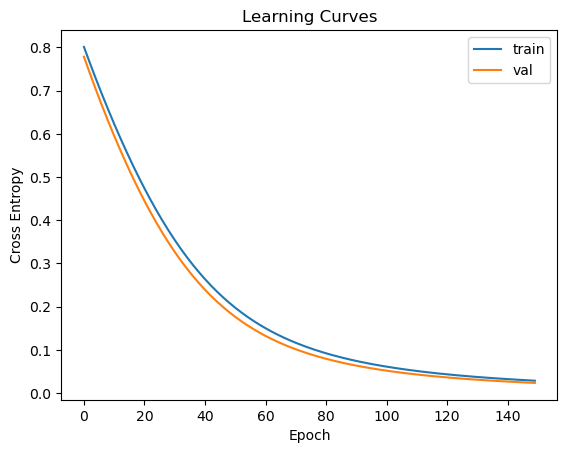

In [1]:
from pandas import read_csv
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from matplotlib import pyplot

df = read_csv('Iris.csv')

X = df.values[:, :-1]
y = df.values[:, -1]

X = X.astype('float32')

y = LabelEncoder().fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle = True, random_state = 123)
print("X_train shape: {}".format(X_train.shape))
print("X_test shape: {}".format(X_test.shape))
print("y_train shape: {}".format(y_train.shape))
print("y_test shape: {}".format(y_test.shape))
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=1)

n_features = X_train.shape[1]

model = Sequential()
model.add(Dense(10, activation='relu', kernel_initializer='he_normal', input_shape=(n_features,)))
model.add(Dense(8, activation='relu', kernel_initializer='he_normal'))
model.add(Dense(3, activation='softmax'))

sgd = SGD(learning_rate=0.001, momentum=0.8)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=150, batch_size=32, verbose=0, validation_split=0.3)

loss, acc = model.evaluate(X_test, y_test, verbose=0)
print('Test Accuracy: %.3f' % acc)

pyplot.title('Learning Curves')
pyplot.xlabel('Epoch')
pyplot.ylabel('Cross Entropy')
pyplot.plot(history.history['loss'], label='train')
pyplot.plot(history.history['val_loss'], label='val')
pyplot.legend()
pyplot.show()

